# Week 41, Tuesday session: building the feed-forward part of a neural network

**FYS-STK3155/4155, Tuesday October 6, 2026 — flipped classroom**

One case today, worked in groups: the feed-forward pass of a fully connected
network, built step by step — one layer by hand with the shapes written out, a
list of layers, an activation function per layer, many samples at once with
the transposed weight convention, and a prediction on a real data set before
any training. These are exactly the steps of this week's exercises
(`exercisesweek41.ipynb`, deadline **Friday October 9 at midnight**), which
you then do on your own on the iris data; here we use the *digits* data of
`scikit-learn` (1797 images of $8\times 8$ pixels, ten classes), so that you
do every step once with us and once alone.

Monday's lecture derived the backward pass, Eqs. (8.65)–(8.68) of the lecture
notes, and ran a complete network on MNIST; today is only the forward pass,
Eq. (8.21) — the part every network needs before anything can be trained.
The optional last step uses `jax.grad` on the cost, which is what next week's
exercises are about.

Insight questions follow the case; answer them in your group before the
plenary.

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score
import jax
jax.config.update("jax_enable_x64", True)   # float64, so that the checks agree with numpy to 1e-15
import jax.numpy as jnp

BLUE, RED, YELLOW, GREY = "#004488", "#BB5566", "#DDAA33", "#777777"
np.set_printoptions(precision=4, suppress=True)

## The activation functions

Written with `jax.numpy` so that the same functions can be differentiated by
`jax.grad` in the optional last step (`jnp` works like `numpy` on ordinary
arrays). `softmax` acts row by row on a matrix of scores — one row per sample
— and subtracts the row maximum first, Eq. (5.30), so that nothing overflows;
`softmax_vec` is the same for a single vector.

In [66]:
def ReLU(z):
    return jnp.where(z > 0, z, 0.0)

def sigmoid(z):
    return 1.0/(1.0 + jnp.exp(-z))

def softmax(z):
    """Softmax of each row of the matrix z: one row of scores per sample."""
    e_z = jnp.exp(z - jnp.max(z, axis=1, keepdims=True))
    return e_z/jnp.sum(e_z, axis=1, keepdims=True)

def softmax_vec(z):
    """Softmax of a single vector of scores."""
    e_z = jnp.exp(z - jnp.max(z))
    return e_z/jnp.sum(e_z)

## The data: 1797 handwritten digits of $8\times 8$ pixels

Each image is flattened to a row of 64 features (pixel values 0–16); the
targets are the digits 0–9. For the network the targets become *one-hot*
rows, Eq. (5.28): a 1 in the column of the correct class, zeros elsewhere.

inputs (1797, 64)  labels (1797,)  one-hot targets (1437, 10)
first label: 6  its one-hot row: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


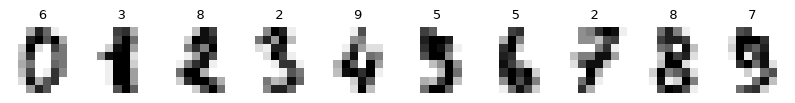

In [78]:
digits = datasets.load_digits()
inputs = digits.data / 16.0                    # 1797 rows, 64 features, scaled to [0, 1]
labels = digits.target
inputs, labels = shuffle(inputs, labels, random_state=2026)  # shuffle the data
inputs_train, inputs_test, labels_train, labels_test = train_test_split(inputs, labels, test_size=0.2, random_state=2026)
targets = np.zeros((len(labels_train), 10))
targets[np.arange(len(labels_train)), labels_train] = 1.0   # one-hot rows
print("inputs", inputs.shape, " labels", labels.shape, " one-hot targets", targets.shape)
print("first label:", labels[0], " its one-hot row:", targets[0])


fig, axes = plt.subplots(1, 10, figsize=(10, 1.4))
for ax, k in zip(axes, range(10)):

    ax.imshow(digits.images[k], cmap="gray_r"); ax.set_title(labels[k], fontsize=9); ax.axis("off")
    
plt.show()


## Case 1, step 1: one layer by hand — the shapes

One input vector $\boldsymbol{x}$ of 64 features and a first layer of 8 nodes.
In the *single-vector* convention of the exercises the weight matrix has shape
(outputs, inputs) and the layer computes

$$
\boldsymbol{z}^1 = \boldsymbol{W}^1\boldsymbol{x} + \boldsymbol{b}^1,\qquad
\boldsymbol{a}^1 = f(\boldsymbol{z}^1),
$$

Eq. (8.20) of the notes, where the book's $\boldsymbol{W}$ is the transpose of
this one. Write the shapes down before running anything: $\boldsymbol{W}^1$ is
$(8, 64)$, $\boldsymbol{x}$ has length 64, so $\boldsymbol{W}^1\boldsymbol{x}$ and
$\boldsymbol{b}^1$ have length 8, and so has $\boldsymbol{a}^1$. The weights are
drawn with the Xavier-like scale $1/\sqrt{\text{inputs}}$ of Monday's
`create_layers` rather than with variance one — with 64 inputs and
$\mathcal{N}(0, 1)$ weights the pre-activations would have standard deviation
$\approx 8\,\mathrm{std}(x)$ and every sigmoid would be saturated before
training starts (Section 8.10).

In [79]:
rng = np.random.default_rng(2026)

x = inputs[0]                                   # one image: 64 features
W1 = rng.normal(0, 1/np.sqrt(64), (8, 64))      # (outputs, inputs)
b1 = np.zeros(8) + 0.01
z1 = W1 @ x + b1
a1 = ReLU(z1)
print("x", x.shape, " W1", W1.shape, " b1", b1.shape, " z1", z1.shape, " a1", a1.shape)
print("z1 =", z1)
print("a1 =", a1, "   (ReLU: the negative entries became 0)")

x (64,)  W1 (8, 64)  b1 (8,)  z1 (8,)  a1 (8,)
z1 = [ 0.2291  0.5159  0.3125 -0.4398 -0.5246  0.0091  0.1517 -0.0519]
a1 = [0.2291 0.5159 0.3125 0.     0.     0.0091 0.1517 0.    ]    (ReLU: the negative entries became 0)


## Case 1, step 2: a list of layers

Writing `W1, b1, W2, b2, ...` by hand does not scale. Keep the layers in a
list of `(W, b)` pairs, built from the input size and the list of output
sizes, and loop over them in the forward pass. With the same activation
(ReLU) in every layer this is a complete network — the function
`feed_forward_all_relu` below is a full feed-forward pass.

In [80]:
def create_layers(network_input_size, layer_output_sizes, rng):
    """A list of (W, b) with W of shape (outputs, inputs): the single-vector convention."""
    layers = []
    i_size = network_input_size
    for layer_output_size in layer_output_sizes:
        W = rng.normal(0, 1/np.sqrt(i_size), (layer_output_size, i_size))
        b = np.zeros(layer_output_size) + 0.01
        layers.append((W, b))
        i_size = layer_output_size
    return layers

def feed_forward_all_relu(layers, x):
    a = x
    for W, b in layers:
        z = W @ a + b
        a = ReLU(z)
    return a

layers = create_layers(64, [16, 8, 10], rng)
for l, (W, b) in enumerate(layers):
    print(f"layer {l + 1}: W {W.shape}  b {b.shape}")
out = feed_forward_all_relu(layers, inputs_train[0])
print("output of the 64-16-8-10 network for the first image:", out)
print("number of parameters:", sum(W.size + b.size for W, b in layers))

layer 1: W (16, 64)  b (16,)
layer 2: W (8, 16)  b (8,)
layer 3: W (10, 8)  b (10,)
output of the 64-16-8-10 network for the first image: [0.     0.     0.077  0.1933 0.     0.0052 0.1284 0.0506 0.     0.0578]
number of parameters: 1266


*Why is a network without activation functions equivalent to a single layer?*
Write it out: $\boldsymbol{W}^3(\boldsymbol{W}^2(\boldsymbol{W}^1\boldsymbol{x} + \boldsymbol{b}^1) + \boldsymbol{b}^2) + \boldsymbol{b}^3 = \tilde{\boldsymbol{W}}\boldsymbol{x} + \tilde{\boldsymbol{b}}$
with $\tilde{\boldsymbol{W}} = \boldsymbol{W}^3\boldsymbol{W}^2\boldsymbol{W}^1$ — one linear map. The
non-linearity between the layers is what buys anything beyond linear
regression (Section 8.2, XOR).

In [71]:
def feed_forward_linear(layers, x):
    a = x
    for W, b in layers:
        a = W @ a + b
    return a

W_tilde = layers[2][0] @ layers[1][0] @ layers[0][0]
b_tilde = layers[2][0] @ (layers[1][0] @ layers[0][1] + layers[1][1]) + layers[2][1]
print("three linear layers:", feed_forward_linear(layers, inputs[0]))
print("one linear layer:   ", W_tilde @ inputs[0] + b_tilde)

three linear layers: [-0.4003 -0.0934 -0.1645 -0.2108  0.0874  0.7631  0.8991  0.4793  0.4929
  0.5327]
one linear layer:    [-0.4003 -0.0934 -0.1645 -0.2108  0.0874  0.7631  0.8991  0.4793  0.4929
  0.5327]


## Case 1, step 3: an activation function per layer

Hidden layers and the output layer usually need different activations
(Section 8.11: the output activation follows the range of the target). Pass a
list of functions — *the function objects, not their values* — and apply the
right one at each layer. For a classification into ten classes the last
activation is the softmax, so that the output is a probability distribution
over the digits.

In [72]:
def feed_forward(x, layers, activation_funcs):
    a = x
    for (W, b), activation_func in zip(layers, activation_funcs):
        z = W @ a + b
        a = activation_func(z)
    return a

activation_funcs = [sigmoid, ReLU, softmax_vec]
layers = create_layers(64, [16, 8, 10], rng)
out = feed_forward(inputs_train[0], layers, activation_funcs)
print("output:", out, "  sum:", float(jnp.sum(out)), "  argmax:", int(jnp.argmax(out)), " true label:", labels[0])

output: [0.2492 0.1444 0.1143 0.0424 0.1608 0.0649 0.0684 0.0479 0.0575 0.0501]   sum: 1.0   argmax: 0  true label: 6


*What changes if you put the sigmoid in the hidden layers and ReLU at the
output?* The output is no longer a distribution: non-negative but not summing
to one, and any node with a negative score gives exactly zero — fine as a
hidden feature, useless as a probability. Try it.

In [73]:
out_relu = feed_forward(inputs_train[0], layers, [sigmoid, sigmoid, ReLU])
print("ReLU at the output:", out_relu, "  sum:", float(jnp.sum(out_relu)))

ReLU at the output: [1.2659 0.2046 0.0204 0.     0.641  0.     0.6794 0.1971 0.0084 0.2479]   sum: 3.2646927997970634


## Case 1, step 4: many samples at once — the batched convention

Sending one vector at a time is clear but slow. With the samples in the
*rows* of a matrix $\boldsymbol{X}$ of shape (samples, features), each layer is
one matrix product and one broadcast addition, Eq. (8.21):

$$
\boldsymbol{Z}^l = \boldsymbol{A}^{l-1}\boldsymbol{W}^l + \boldsymbol{b}^l,\qquad
\boldsymbol{A}^l = f(\boldsymbol{Z}^l),
$$

and now $\boldsymbol{W}^l$ has shape (inputs, outputs) — the *transpose* of the
single-vector convention. Monday's code and the lecture notes use this
batched convention throughout; the exercises make you write both so that you
never mix them up (the single most frequent source of shape errors, Section
8.5). Only two things change: the weight shape in `create_layers_batch` and
the order of the product, `a @ W` instead of `W @ a`. The bias is added to
every row by broadcasting, and `softmax` (the row version) replaces
`softmax_vec`.

In [81]:
def create_layers_batch(network_input_size, layer_output_sizes, rng):
    """A list of (W, b) with W of shape (inputs, outputs): the batched convention of Eq. (8.21)."""
    layers = []
    i_size = network_input_size
    for layer_output_size in layer_output_sizes:
        W = rng.normal(0, 1/np.sqrt(i_size), (i_size, layer_output_size))
        b = np.zeros(layer_output_size) + 0.01
        layers.append((W, b))
        i_size = layer_output_size
    return layers

def feed_forward_batch(inputs, layers, activation_funcs):
    a = inputs
    for (W, b), activation_func in zip(layers, activation_funcs):
        z = a @ W + b
        a = activation_func(z)
    return a

activation_funcs = [sigmoid, ReLU, softmax]
layers_batch = create_layers_batch(64, [16, 8, 10], rng)
out_all = feed_forward_batch(inputs_train, layers_batch, activation_funcs)
print("inputs", inputs_train.shape, "-> output", out_all.shape)
print("row sums of the softmax output (first five):", np.asarray(jnp.sum(out_all, axis=1))[:5])

# the same network in the single-vector convention: transpose every W, use softmax_vec
layers_single = [(W.T, b) for W, b in layers_batch]
out_one = feed_forward(inputs_train[0], layers_single, [sigmoid, ReLU, softmax_vec])
print("batched row 0 against the single-vector pass, max difference:", float(jnp.max(jnp.abs(out_all[0] - out_one))))

inputs (1437, 64) -> output (1437, 10)
row sums of the softmax output (first five): [1. 1. 1. 1. 1.]
batched row 0 against the single-vector pass, max difference: 2.7755575615628914e-17


## Case 1, step 5: predicting on the real data before any training

A 64–32–10 network, sigmoid hidden layer and softmax output, evaluated on all
1797 digits at once. The prediction is the class with the largest probability.
Before training, the weights are random: the accuracy should be close to the
$10\%$ of guessing, and recreating the network with new random weights moves
it around that value — the network has learned nothing yet, which is the
point. (The exercises ask for the same on the iris data: 4 features, 8 hidden
nodes, 3 classes, where guessing gives $33\%$.)

In [93]:
def accuracy(predictions, targets):
    """Fraction of rows whose largest predicted probability sits in the correct class."""
    predicted_classes = np.argmax(np.asarray(predictions), axis=1)
    target_classes = np.argmax(targets, axis=1) if np.asarray(targets).ndim > 1 else targets
    return accuracy_score(predicted_classes, target_classes)

activation_funcs = [sigmoid, softmax]
accuracies = []
for trial in range(5):
    layers_batch = create_layers_batch(64, [32, 10], rng)
    predictions = feed_forward_batch(inputs_train, layers_batch, activation_funcs)
    accuracies.append(accuracy(predictions, targets))
print("accuracy of five untrained 64-32-10 networks:", np.round(accuracies, 4))
print("predicted classes of the first 20 digits:", np.argmax(np.asarray(predictions), axis=1)[:20])
print("true classes of the first 20 digits:     ", labels_train[:20])
print("largest probability per row, mean:", float(jnp.mean(jnp.max(predictions, axis=1))))

accuracy of five untrained 64-32-10 networks: [0.0932 0.0995 0.1002 0.0932 0.1002]
predicted classes of the first 20 digits: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
true classes of the first 20 digits:      [7 4 5 2 0 3 7 7 3 7 4 1 0 6 3 4 3 8 2 3]
largest probability per row, mean: 0.2328592484226772


## Case 1, step 6 (optional): the cost, its gradient with `jax.grad`, and a few steps of training

Everything so far needs only the forward pass. To *train* the network we need
the cost — the multiclass cross entropy of Eq. (5.28), averaged over the
samples — and its gradient with respect to every weight and bias. Monday
derived that gradient (backpropagation); here `jax.grad` computes it from the
forward pass alone. `cost` takes the layers as its second argument, so
`jax.grad(cost, argnums=1)` returns a list of `(dW, db)` pairs with exactly the
shapes of the layers. Then plain gradient descent, Eq. (8.70), for a few
hundred steps on all 1797 samples: the accuracy climbs from $10\%$ to above
$90\%$. Next week's exercises implement this gradient by hand and compare it
with `jax.grad`.

In [94]:
def cross_entropy(predict, target):
    return -jnp.mean(jnp.sum(target * jnp.log(predict + 1e-12), axis=1))

def cost(inputs, layers, activation_funcs, target):
    predict = feed_forward_batch(inputs, layers, activation_funcs)
    return cross_entropy(predict, target)

activation_funcs = [ReLU, softmax]
gradient_func = jax.grad(cost, argnums=1)       # the gradient with respect to the layers

layers_batch = create_layers_batch(64, [32, 10], rng)
layers_grad = gradient_func(inputs_train, layers_batch, activation_funcs, targets)
for l, ((W, b), (dW, db)) in enumerate(zip(layers_batch, layers_grad)):
    print(f"layer {l + 1}: W {W.shape} dW {dW.shape}   b {b.shape} db {db.shape}")

def train_network(inputs, layers, activation_funcs, targets, gamma=1.0, epochs=1000):
    history = []
    for epoch in range(epochs):
        layers_grad = gradient_func(inputs, layers, activation_funcs, targets)
        layers = [(W - gamma*dW, b - gamma*db) for (W, b), (dW, db) in zip(layers, layers_grad)]
        if epoch % 50 == 0 or epoch == epochs - 1:
            predictions = feed_forward_batch(inputs, layers, activation_funcs)
            history.append((epoch, float(cost(inputs, layers, activation_funcs, targets)), accuracy(predictions, targets)))
    return layers, history

trained, history = train_network(inputs_train, layers_batch, activation_funcs, targets)

for epoch, c, acc in history:
    print(f"epoch {epoch:4d}: cost {c:.4f}  accuracy {acc:.4f}")
    print("predicted classes of the first 20 digits:", np.argmax(np.asarray(feed_forward_batch(inputs_train, trained, activation_funcs)), axis=1)[:20])
    print("true classes of the first 20 digits:     ", labels_train[:20])
    print("The accuracy is ", acc)

test_predictions = feed_forward_batch(inputs_test, trained, activation_funcs)
test_accuracy = accuracy(test_predictions, labels_test)
print("test accuracy of the trained network:", test_accuracy)
print("predicted classes of the first 20 test digits:", np.argmax(np.asarray(test_predictions), axis=1)[:20])
print("true classes of the first 20 test digits:     ", labels_test[:20])

layer 1: W (64, 32) dW (64, 32)   b (32,) db (32,)
layer 2: W (32, 10) dW (32, 10)   b (10,) db (10,)
epoch    0: cost 2.2199  accuracy 0.1677
predicted classes of the first 20 digits: [7 4 5 2 0 3 7 7 3 7 4 1 0 6 3 4 3 8 2 3]
true classes of the first 20 digits:      [7 4 5 2 0 3 7 7 3 7 4 1 0 6 3 4 3 8 2 3]
The accuracy is  0.1677105080027836
epoch   50: cost 0.2491  accuracy 0.9228
predicted classes of the first 20 digits: [7 4 5 2 0 3 7 7 3 7 4 1 0 6 3 4 3 8 2 3]
true classes of the first 20 digits:      [7 4 5 2 0 3 7 7 3 7 4 1 0 6 3 4 3 8 2 3]
The accuracy is  0.9227557411273486
epoch  100: cost 0.1095  accuracy 0.9729
predicted classes of the first 20 digits: [7 4 5 2 0 3 7 7 3 7 4 1 0 6 3 4 3 8 2 3]
true classes of the first 20 digits:      [7 4 5 2 0 3 7 7 3 7 4 1 0 6 3 4 3 8 2 3]
The accuracy is  0.9728601252609603
epoch  150: cost 0.0762  accuracy 0.9861
predicted classes of the first 20 digits: [7 4 5 2 0 3 7 7 3 7 4 1 0 6 3 4 3 8 2 3]
true classes of the first 20 digits:  

A single learning rate, no minibatches, no test set — this is the whole
training set and therefore *not* a measure of generalisation (Section 3.14);
it only shows that the gradient from `jax.grad` points downhill. The honest
version, with a train/test split, minibatches and the optimisers of week 38,
is next week.

## Case 1: do you have the insight?

1. A network with three layers and *no* activation functions gave the same
   output as one layer with $\tilde{\boldsymbol{W}} = \boldsymbol{W}^3\boldsymbol{W}^2\boldsymbol{W}^1$.
   Which property of linear maps is responsible, and what does the universal
   approximation theorem (Section 8.4) require of the activation to avoid it?
2. The single-vector convention stores $\boldsymbol{W}$ as (outputs, inputs) and
   computes $\boldsymbol{W}\boldsymbol{x}$; the batched convention stores
   (inputs, outputs) and computes $\boldsymbol{X}\boldsymbol{W}$. Why does putting the
   samples in rows force the transpose, and which one does the backward pass
   of Monday (`delta @ W.T`, `a.T @ delta`) assume?
3. Five untrained networks gave accuracies of about $10\%$ on ten classes,
   the largest probability per row averaged only $0.17$, and almost every
   image was assigned one of the same two classes. Why is that what random
   weights produce, what would the output look like if the last activation
   were ReLU or the sigmoid instead of the softmax, and why does the
   multiclass cross entropy need the softmax?
4. We drew the weights with scale $1/\sqrt{\text{inputs}}$. With $\mathcal{N}(0,1)$
   weights and 64 inputs, what is the typical size of $z^1$ for a sigmoid
   hidden layer, what does $\sigma'(z^1)$ become, and what would Monday's
   backward pass deliver to the first layer?

*What we hope you say.* (1) Matrix products are matrices: the composition of
linear maps is linear, so depth without non-linearity adds parameters but no
functions; the theorem needs a non-polynomial activation. (2) A row vector
times a matrix is $\boldsymbol{x}^T\boldsymbol{W}$, the transpose of
$\boldsymbol{W}^T\boldsymbol{x}$: the batched $\boldsymbol{W}$ is the transpose of the
single-vector one, and Monday's code assumes the batched convention
throughout. (3) With random weights the ten scores differ by small
random amounts that depend little on the image, so the softmax is nearly
flat and the largest entry is whichever node happened to get the largest
bias plus weights -- the same for most images. ReLU at the output gives
non-negative numbers that do not sum to one and exact zeros; the sigmoid
gives ten independent numbers in $(0,1)$; only the softmax is a distribution
over the classes, and the cross entropy $-\ln a_{k^*}$ needs a probability
of the correct class. (4) $z^1$ is a sum
of 64 terms of order one, standard deviation $\approx 8\,\mathrm{std}(x)$;
most units sit where $\sigma' \approx 0$, and Eq. (8.66) multiplies the error
by that $\sigma'$ — the first layer receives almost no gradient and training
stalls, the $\gamma = 1$ run of week 40 with 32 neurons.